In [ ]:
import subprocess

"""
build_dataset_financeai.py
===========================
Team 38 (LATAM) · Oracle ONE G9 · Proyecto FinanceAI

Construye el dataset híbrido explícito (Propuesta 3):
  - Capa 1 (real):    transacciones reales anonimizadas -> entrena el clasificador de gastos
  - Capa 2 (sintética): perfil financiero por usuario -> calcula perfil_financiero + recomendaciones

Uso:
    1. pip install -r requirements.txt
    2. Configurar credenciales de Kaggle (ver función descargar_datasets)
    3. python build_dataset_financeai.py

Salida:
    data/processed/financeai_dataset_hibrido.csv
"""

from pathlib import Path

import numpy as np
import pandas as pd

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================
RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

N_USUARIOS = 500          # número de usuarios sintéticos a generar
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Las 8 categorías definidas para el proyecto FinanceAI
CATEGORIAS_PROYECTO = [
    "Alimentación", "Transporte", "Salud", "Vivienda",
    "Educación", "Ocio", "Servicios", "Otros",
]

# Mapeo de categorías originales del dataset de Kaggle -> categorías del proyecto.
# IMPORTANTE: ajustar estas llaves según los valores reales de la columna "category"
# del CSV descargado (varían según el dataset; revisar con df["category"].unique()).
MAPEO_CATEGORIAS = {
    "groceries": "Alimentación",
    "restaurant": "Alimentación",
    "food": "Alimentación",
    "supermarket": "Alimentación",
    "transport": "Transporte",
    "fuel": "Transporte",
    "taxi": "Transporte",
    "public transport": "Transporte",
    "health": "Salud",
    "pharmacy": "Salud",
    "medical": "Salud",
    "rent": "Vivienda",
    "housing": "Vivienda",
    "mortgage": "Vivienda",
    "utilities": "Servicios",
    "bills": "Servicios",
    "internet": "Servicios",
    "education": "Educación",
    "tuition": "Educación",
    "books": "Educación",
    "entertainment": "Ocio",
    "streaming": "Ocio",
    "leisure": "Ocio",
    "shopping": "Otros",
    "other": "Otros",
}


# ============================================================
# PASO 1 · Descarga de los datasets fuente (Kaggle API)
# ============================================================
def descargar_datasets():
    """
    Requiere:
      pip install kaggle
      Un token de API de Kaggle en ~/.kaggle/kaggle.json
      (Kaggle > Account > Create New API Token)

    Descarga las dos fuentes usadas en la metodología híbrida:
      - Capa 1: transacciones reales anonimizadas
      - Capa 2: perfil financiero de referencia
    """

    datasets = [
        "artemkabseu/financial-transactions-dataset-expenses-and-income",  # Capa 1
        "miadul/personal-finance-ml-dataset",                              # Capa 2
    ]
    for ds in datasets:
        subprocess.run(
            ["kaggle", "datasets", "download", "-d", ds, "-p", str(RAW_DIR), "--unzip"],
            check=True,
        )


# ============================================================
# PASO 2 · Cargar y normalizar Capa 1 (transacciones reales)
# ============================================================
def cargar_capa1_transacciones(path_csv: Path) -> pd.DataFrame:
    """
    Carga el CSV de transacciones y lo deja en el esquema estándar del proyecto:
    fecha, descripcion, categoria, valor.

    NOTA: los nombres de columnas de "rename" deben ajustarse a los nombres reales
    del CSV descargado (inspeccionar con df.columns antes de correr en producción).
    """
    df = pd.read_csv(path_csv)
    # print(f"Columnas en el CSV: {df.columns.tolist()}")
    # Temporary return to inspect columns
    # return df

    df = df.rename(columns={
        "date_time": "fecha", # Updated from 'date'
        "tags": "descripcion", # Updated from 'description' to 'tags'
        "category": "categoria_original",
        "amount": "valor",
    })

    columnas_requeridas = {"fecha", "descripcion", "categoria_original", "valor"}
    faltantes = columnas_requeridas - set(df.columns)
    if faltantes:
        raise ValueError(
            f"Faltan columnas esperadas tras el rename: {faltantes}. "
            "Revisa los nombres reales del CSV descargado y ajusta el diccionario de 'rename'."
        )

    df["categoria"] = (
        df["categoria_original"].astype(str).str.strip().str.lower().map(MAPEO_CATEGORIAS)
    )
    df["categoria"] = df["categoria"].fillna("Otros")

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce").abs()
    df = df.dropna(subset=["valor"])

    return df[["fecha", "descripcion", "categoria", "valor"]].reset_index(drop=True)


# ============================================================
# PASO 3 · Generar usuario_id sintético y distribuir transacciones
# ============================================================
def asignar_usuarios(df_transacciones: pd.DataFrame, n_usuarios: int = N_USUARIOS):
    """
    Genera IDs de usuario sintéticos y distribuye las transacciones reales entre ellos.
    La distribución no es uniforme (algunos usuarios "gastan más" que otros), usando
    una distribución de Dirichlet para simular variabilidad realista.
    """
    usuario_ids = [f"user_{i:04d}" for i in range(n_usuarios)]

    pesos = np.random.dirichlet(np.ones(n_usuarios) * 2)
    df = df_transacciones.copy()
    df["usuario_id"] = np.random.choice(usuario_ids, size=len(df), p=pesos)

    return df, usuario_ids


# ============================================================
# PASO 4 · Cargar Capa 2 (perfil financiero) como referencia estadística
# ============================================================
def cargar_capa2_referencia(path_csv: Path) -> pd.DataFrame:
    """
    Carga el dataset de perfil financiero público SOLO como referencia estadística
    (no se usa como verdad de campo directa). Ajustar nombres de columnas según el
    CSV real descargado.
    """
    df = pd.read_csv(path_csv)

    df = df.rename(columns={
        "monthly_income_usd": "ingreso_mensual",
        "debt_to_income_ratio": "nivel_endeudamiento",
        "savings_to_income_ratio": "ratio_ahorro",
        "credit_score": "score_crediticio",
    })

    columnas_requeridas = {"ingreso_mensual", "nivel_endeudamiento", "ratio_ahorro", "score_crediticio"}
    faltantes = columnas_requeridas - set(df.columns)
    if faltantes:
        raise ValueError(
            f"Faltan columnas esperadas tras el rename: {faltantes}. "
            "Revisa los nombres reales del CSV descargado y ajusta el diccionario de 'rename'."
        )

    return df[list(columnas_requeridas)].dropna()


def generar_perfiles_sinteticos(usuario_ids, df_referencia: pd.DataFrame) -> pd.DataFrame:
    """
    Genera el perfil financiero sintético de cada usuario_id MUESTREANDO del dataset de
    referencia (con reemplazo) en vez de copiarlo directamente, y agregando ruido leve.
    Esto calibra distribuciones realistas sin usar la fuente como verdad exacta.
    """
    muestra = (
        df_referencia
        .sample(n=len(usuario_ids), replace=True, random_state=RANDOM_SEED)
        .reset_index(drop=True)
    )
    muestra["usuario_id"] = usuario_ids

    # Ruido leve (±10%) para que no sean copias exactas de la fuente de referencia
    ruido = np.random.uniform(0.9, 1.1, size=len(muestra))
    muestra["ingreso_mensual"] = (muestra["ingreso_mensual"] * ruido).round(2)
    muestra["nivel_endeudamiento"] = muestra["nivel_endeudamiento"].clip(0, 1)

    # frecuencia_ahorro categórica derivada del ratio de ahorro
    muestra["frecuencia_ahorro"] = pd.cut(
        muestra["ratio_ahorro"],
        bins=[-np.inf, 0.05, 0.15, np.inf],
        labels=["Baja", "Media", "Alta"],
    ).astype(str)

    return muestra[[
        "usuario_id", "ingreso_mensual", "nivel_endeudamiento",
        "frecuencia_ahorro", "score_crediticio",
    ]]


# ============================================================
# PASO 5 · Función de scoring del perfil financiero (regla explícita del equipo)
# ============================================================
def calcular_perfil_financiero(row) -> str:
    """
    Regla de negocio documentada por el equipo (no aprendida de datos):
    combina ratio gasto/ingreso, nivel de endeudamiento y frecuencia de ahorro
    en un puntaje de riesgo simple.
    """
    riesgo = 0

    if row["ratio_gasto_ingreso"] > 0.9:
        riesgo += 2
    elif row["ratio_gasto_ingreso"] > 0.7:
        riesgo += 1

    if row["nivel_endeudamiento"] > 0.4:
        riesgo += 2
    elif row["nivel_endeudamiento"] > 0.25:
        riesgo += 1

    if row["frecuencia_ahorro"] == "Baja":
        riesgo += 1
    elif row["frecuencia_ahorro"] == "Alta":
        riesgo -= 1

    if riesgo >= 3:
        return "En riesgo"
    if riesgo >= 1:
        return "En observación"
    return "Saludable"


def generar_recomendaciones(row) -> list:
    """Genera recomendaciones simples y objetivas según el perfil calculado."""
    recomendaciones = []

    if row["ratio_gasto_ingreso"] > 0.8:
        recomendaciones.append("Reducir gastos recurrentes en las categorías de mayor peso")
    if row["nivel_endeudamiento"] > 0.35:
        recomendaciones.append("Priorizar el pago de deuda antes de nuevos compromisos financieros")
    if row["frecuencia_ahorro"] == "Baja":
        recomendaciones.append("Aumentar la frecuencia de ahorro mensual")
    if not recomendaciones:
        recomendaciones.append("Mantener los hábitos financieros actuales")

    return recomendaciones


# ============================================================
# PASO 6 · Unir Capa 1 + Capa 2 en el dataset final
# ============================================================
def construir_dataset_final(df_transacciones_usuario: pd.DataFrame, df_perfiles: pd.DataFrame) -> pd.DataFrame:
    resumen_gastos = (
        df_transacciones_usuario
        .groupby(["usuario_id", "categoria"])["valor"]
        .sum()
        .unstack(fill_value=0)
        .reset_index()
    )

    # Asegurar que todas las categorías del proyecto existan como columnas, aunque no
    # tengan transacciones para algún usuario.
    for cat in CATEGORIAS_PROYECTO:
        if cat not in resumen_gastos.columns:
            resumen_gastos[cat] = 0.0

    df_final = df_perfiles.merge(resumen_gastos, on="usuario_id", how="left")
    df_final[CATEGORIAS_PROYECTO] = df_final[CATEGORIAS_PROYECTO].fillna(0.0)

    df_final["gasto_total"] = df_final[CATEGORIAS_PROYECTO].sum(axis=1)
    df_final["ratio_gasto_ingreso"] = (
        df_final["gasto_total"] / df_final["ingreso_mensual"].replace(0, np.nan)
    ).fillna(0)

    df_final["perfil_financiero"] = df_final.apply(calcular_perfil_financiero, axis=1)
    df_final["recomendaciones"] = df_final.apply(generar_recomendaciones, axis=1)

    return df_final


# ============================================================
# MAIN
# ============================================================
def main():
    # Descomentar si aún no se han descargado los CSV y ya se configuró la API de Kaggle:
    descargar_datasets()

    ruta_capa1 = RAW_DIR / "Expenses_clean.csv"   # ajustar al nombre real descargado
    ruta_capa2 = RAW_DIR / "synthetic_personal_finance_dataset.csv"      # ajustar al nombre real descargado

    print("Cargando Capa 1 (transacciones reales)...")
    df_transacciones = cargar_capa1_transacciones(ruta_capa1)

    print("Asignando transacciones a usuarios sintéticos...")
    df_transacciones_usuario, usuario_ids = asignar_usuarios(df_transacciones)

    print("Cargando Capa 2 (perfil financiero de referencia)...")
    df_referencia = cargar_capa2_referencia(ruta_capa2)

    print("Generando perfiles financieros sintéticos...")
    df_perfiles = generar_perfiles_sinteticos(usuario_ids, df_referencia)

    print("Construyendo dataset final (Capa 1 + Capa 2)....")
    df_final = construir_dataset_final(df_transacciones_usuario, df_perfiles)

    salida = PROCESSED_DIR / "financeai_dataset_hibrido.csv"
    df_final.to_csv(salida, index=False)

    print(f"\nListo. Dataset final: {len(df_final)} usuarios -> {salida}")
    print(df_final["perfil_financiero"].value_counts())


if __name__ == "__main__":
    main()

Cargando Capa 1 (transacciones reales)...
Asignando transacciones a usuarios sintéticos...
Cargando Capa 2 (perfil financiero de referencia)...
Generando perfiles financieros sintéticos...
Construyendo dataset final (Capa 1 + Capa 2)....

Listo. Dataset final: 500 usuarios -> data/processed/financeai_dataset_hibrido.csv
perfil_financiero
Saludable         351
En observación    149
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load the generated dataset
df_hibrido = pd.read_csv('data/processed/financeai_dataset_hibrido.csv')

# Display the first 5 rows
display(df_hibrido.head())

,usuario_id,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,score_crediticio,Alimentación,Ocio,Otros,Salud,Transporte,Vivienda,Educación,Servicios,gasto_total,ratio_gasto_ingreso,perfil_financiero,recomendaciones
0,user_0000,5427.58,0.00,Alta,539,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,Saludable,['Mantener los hábitos financieros actuales']
1,user_0001,5946.28,1.00,Alta,575,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000168,En observación,['Priorizar el pago de deuda antes de nuevos c...
2,user_0002,3968.19,0.00,Alta,741,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0,0.000756,Saludable,['Mantener los hábitos financieros actuales']
3,user_0003,537.96,1.00,Alta,779,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.003718,En observación,['Priorizar el pago de deuda antes de nuevos c...
4,user_0004,4952.41,0.38,Alta,592,0.0,0.0,32.0,0.0,2.0,0.0,0.0,0.0,34.0,0.006865,Saludable,['Priorizar el pago de deuda antes de nuevos c...


In [ ]:
# Calculate the Pearson correlation between 'score_crediticio' and 'ratio_gasto_ingreso'
correlation = df_hibrido['score_crediticio'].corr(df_hibrido['ratio_gasto_ingreso'])
print(f"Pearson correlation between score_crediticio and ratio_gasto_ingreso: {correlation:.4f}")

Pearson correlation between score_crediticio and ratio_gasto_ingreso: 0.0046


The Pearson correlation coefficient ranges from -1 to +1.
- A value of +1 indicates a perfect positive linear relationship.
- A value of -1 indicates a perfect negative linear relationship.
- A value of 0 indicates no linear relationship.

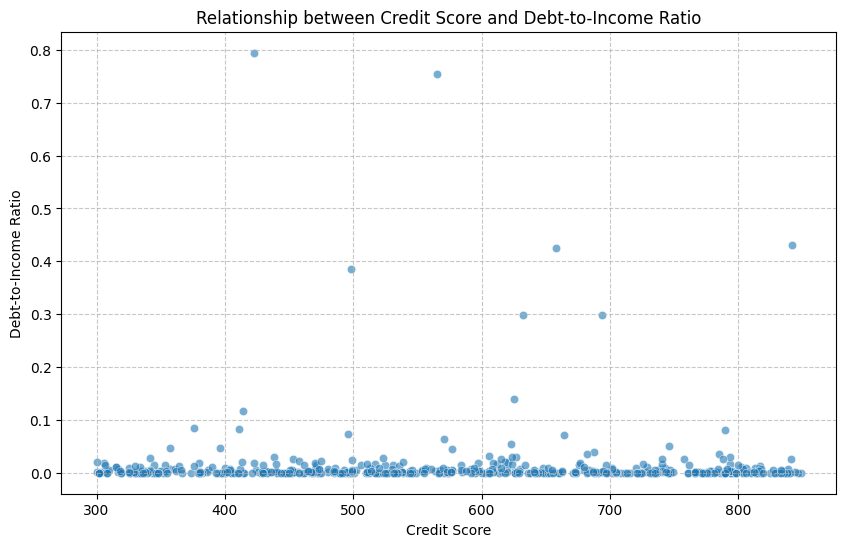

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='score_crediticio', y='ratio_gasto_ingreso', data=df_hibrido, alpha=0.6)
plt.title('Relationship between Credit Score and Debt-to-Income Ratio')
plt.xlabel('Credit Score')
plt.ylabel('Debt-to-Income Ratio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_347/2610643229.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='perfil_financiero', y='ratio_gasto_ingreso', data=df_hibrido, palette='viridis')


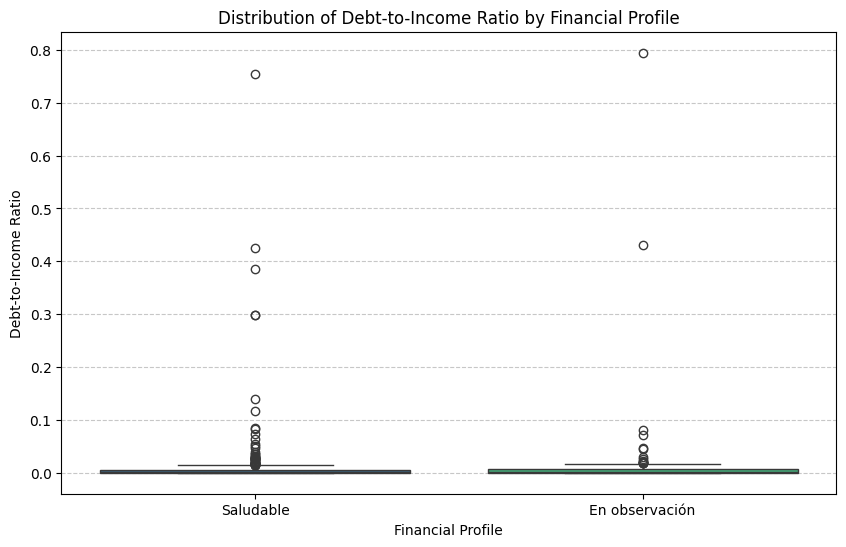

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='perfil_financiero', y='ratio_gasto_ingreso', data=df_hibrido, palette='viridis')
plt.title('Distribution of Debt-to-Income Ratio by Financial Profile')
plt.xlabel('Financial Profile')
plt.ylabel('Debt-to-Income Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
average_ingreso_mensual = df_hibrido.groupby('perfil_financiero')['ingreso_mensual'].mean().reset_index()
display(average_ingreso_mensual)

,perfil_financiero,ingreso_mensual
0,En observación,3792.924832
1,Saludable,4155.942393


/tmp/ipykernel_347/4036931143.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='perfil_financiero', y='nivel_endeudamiento', data=df_hibrido, palette='viridis')


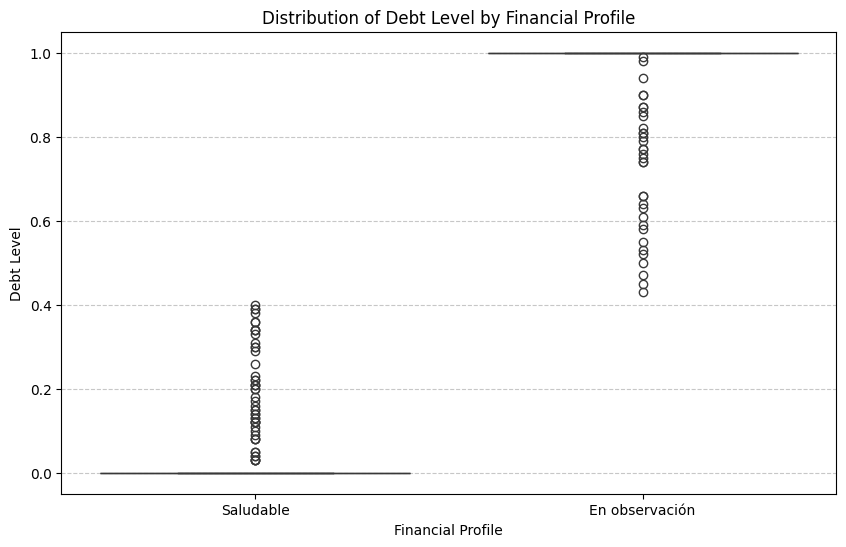

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='perfil_financiero', y='nivel_endeudamiento', data=df_hibrido, palette='viridis')
plt.title('Distribution of Debt Level by Financial Profile')
plt.xlabel('Financial Profile')
plt.ylabel('Debt Level')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

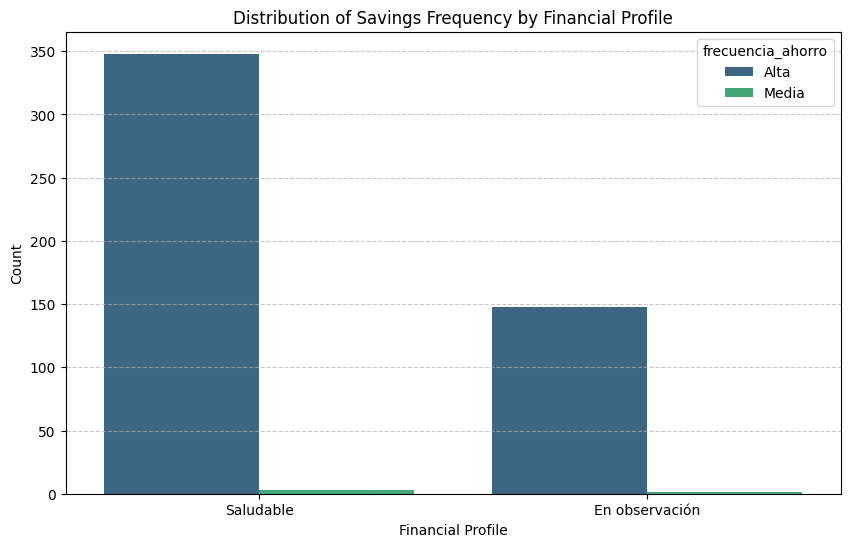

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='perfil_financiero', hue='frecuencia_ahorro', data=df_hibrido, palette='viridis')
plt.title('Distribution of Savings Frequency by Financial Profile')
plt.xlabel('Financial Profile')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()